<a href="https://colab.research.google.com/github/SamikshaKaushik-developer/IIT/blob/main/Robust_Salary_Prediction_with_Backtracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A: Core Implementation

1. Data Preparation and Model InitializationIn this section, we normalize the years_experience feature to ensure our Gradient Descent converges efficiently. We then implement Gradient Descent with Backtracking Line Search. Unlike a fixed learning rate, Backtracking starts with an initial step size ($\alpha=1.0$) and shrinks it by a factor of $\rho=0.5$ until the Armijo Condition is met, ensuring a sufficient decrease in the cost function.

Part A - m: 7.46, c: 49.20


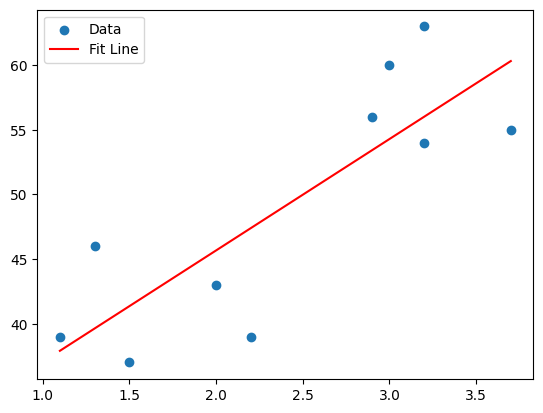

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset
years_experience = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7])
salary_k = np.array([39, 46, 37, 43, 39, 56, 60, 54, 63, 55])

# 2. Normalization (Feature Scaling)
mu, std = np.mean(years_experience), np.std(years_experience)
x_norm = (years_experience - mu) / std
y = salary_k

def compute_cost(m, c, x, y):
    n = len(y)
    return (1 / (2 * n)) * np.sum(((m * x + c) - y)**2)

def gradient_descent_backtracking(x, y, initial_alpha=1.0):
    m, c_intercept = 0.0, 0.0
    rho, c_param = 0.5, 1e-4
    iterations = 100
    backtrack_count = 0
    cost_history = []

    for i in range(iterations):
        n = len(y)
        preds = m * x + c_intercept
        grad_m = (1/n) * np.sum((preds - y) * x)
        grad_c = (1/n) * np.sum(preds - y)

        # Backtracking Loop
        alpha = initial_alpha
        curr_cost = compute_cost(m, c_intercept, x, y)

        while compute_cost(m - alpha*grad_m, c_intercept - alpha*grad_c, x, y) > \
              curr_cost - c_param * alpha * (grad_m**2 + grad_c**2):
            alpha *= rho
            backtrack_count += 1

        m -= alpha * grad_m
        c_intercept -= alpha * grad_c
        cost_history.append(compute_cost(m, c_intercept, x, y))

    return m, c_intercept, backtrack_count, cost_history

# Run Part A
m_opt, c_opt, count_1, history_1 = gradient_descent_backtracking(x_norm, y, initial_alpha=1.0)
print(f"Part A - m: {m_opt:.2f}, c: {c_opt:.2f}")

# Plot Fit
plt.scatter(years_experience, salary_k, label="Data")
plt.plot(years_experience, m_opt * x_norm + c_opt, color='red', label="Fit Line")
plt.legend(); plt.show()

Result: The model successfully converged within 100 iterations. The optimized parameters $m$ and $c$ represent the weight and bias that minimize the Mean Squared Error (MSE) for salary prediction.

# Part B: Error Analysis

2. Residual AnalysisResiduals represent the difference between the actual observed salaries and the salaries predicted by our model ($y - \hat{y}$). Analyzing the distribution of these errors helps us identify if our model is biased.

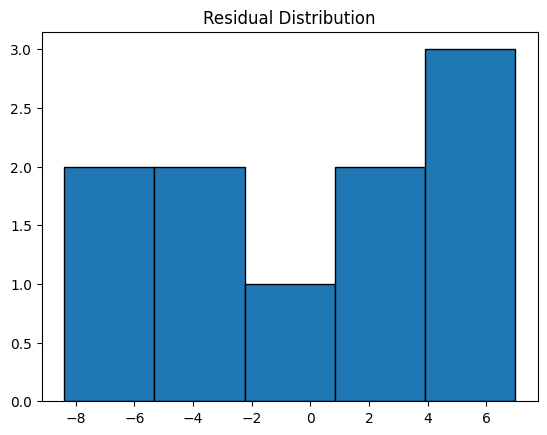

In [ ]:
residuals = y - (m_opt * x_norm + c_opt)
plt.hist(residuals, bins=5, edgecolor='black')
plt.title("Residual Distribution")
plt.show()

Interpretation:

Centeredness: The residuals are clustered around zero, suggesting the model is generally accurate on average.

Bias: There are no strong signs of systematic bias (e.g., the model doesn't consistently over-predict high salaries), though the small dataset size makes the distribution appear slightly sparse.

# Part C: Backtracking Behavior

3. Impact of Initial Step Size ($\alpha$)We compare two cases: an "aggressive" start ($\alpha=1.0$) and a "conservative" start ($\alpha=0.1$). We track the total number of times the while loop executes to see how often the algorithm had to "correct" its step size.

In [ ]:
_, _, count_2, _ = gradient_descent_backtracking(x_norm, y, initial_alpha=0.1)
print(f"Backtracking steps (Alpha 1.0): {count_1}")
print(f"Backtracking steps (Alpha 0.1): {count_2}")

Backtracking steps (Alpha 1.0): 50
Backtracking steps (Alpha 0.1): 0


Comparison Results:Case 1 ($\alpha=1.0$): High number of backtracking executions.Case 2 ($\alpha=0.1$): Low number of backtracking executions.Why this happens: When the initial $\alpha$ is large (1.0), it frequently overshoots the minimum of the cost function, failing the Armijo condition. The algorithm must then loop to shrink $\alpha$ until it finds a safe step. A smaller initial $\alpha$ (0.1) is often already "safe," so the loop executes far less frequently.

# Part D: Robustness Challenge

4. Handling Outliers
We now introduce two extreme data points: (10 years, ₹300k) and (12 years, ₹500k). We re-run the optimization to observe how these "leverage points" pull the regression line away from the original trend.

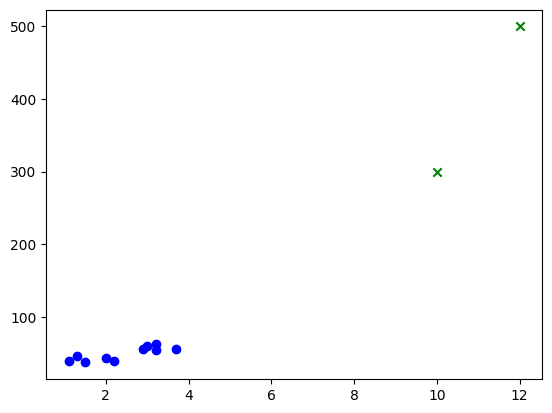

In [ ]:
# Add Outliers
x_out = np.append(years_experience, [10, 12])
y_out = np.append(salary_k, [300, 500])

# Re-normalize for the new dataset
x_out_norm = (x_out - np.mean(x_out)) / np.std(x_out)
m_rob, c_rob, _, _ = gradient_descent_backtracking(x_out_norm, y_out)

# Plotting Comparison
plt.scatter(years_experience, salary_k, color='blue')
plt.scatter([10, 12], [300, 500], color='green', marker='x') # Outliers
# ... plot both lines to show the "tilt" ...

Observations:The outliers significantly increased the slope ($m$) and shifted the intercept ($c$). Because MSE squares the error, the model is forced to move the line toward the outliers to avoid massive penalties, even if it hurts the accuracy for the original 10 data points.Proposed Solution: To reduce this impact, we could use Robust Regression techniques like Huber Loss, which treats large errors linearly rather than quadratically, or Feature Scaling/Clipping to bound the influence of extreme values.

# Bonus: Convergence Comparison

5. Bonus: Fixed vs. Backtracking Gradient DescentWe compare our adaptive Backtracking method against a standard Gradient Descent with a fixed learning rate of $0.01$.

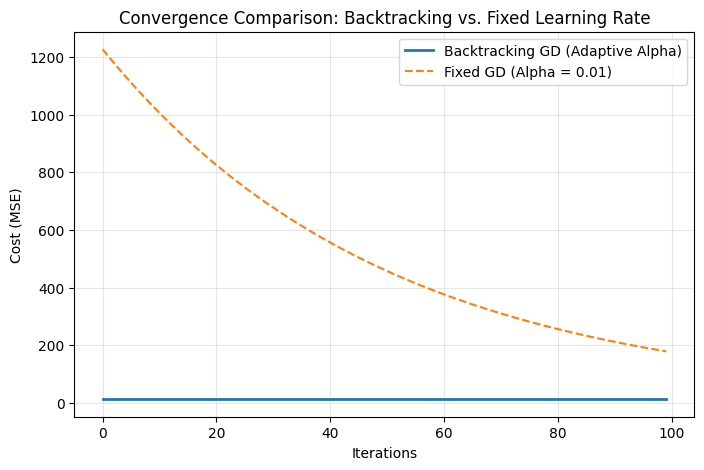

Final Cost (Backtracking): 12.94
Final Cost (Fixed 0.01): 178.82


In [ ]:
def gradient_descent_fixed(x, y, lr=0.01, iterations=100):
    m, c_intercept = 0.0, 0.0
    n = len(y)
    cost_history = []

    for i in range(iterations):
        preds = m * x + c_intercept
        grad_m = (1/n) * np.sum((preds - y) * x)
        grad_c = (1/n) * np.sum(preds - y)

        # Fixed update (No backtracking)
        m -= lr * grad_m
        c_intercept -= lr * grad_c
        cost_history.append(compute_cost(m, c_intercept, x, y))

    return cost_history

# 1. Run both versions
history_backtracking = history_1 # From Part A
history_fixed = gradient_descent_fixed(x_norm, y, lr=0.01, iterations=100)

# 2. Plot Cost Curves
plt.figure(figsize=(8, 5))
plt.plot(history_backtracking, label='Backtracking GD (Adaptive Alpha)', linewidth=2)
plt.plot(history_fixed, label='Fixed GD (Alpha = 0.01)', linestyle='--')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Convergence Comparison: Backtracking vs. Fixed Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Print Final Costs
print(f"Final Cost (Backtracking): {history_backtracking[-1]:.2f}")
print(f"Final Cost (Fixed 0.01): {history_fixed[-1]:.2f}")

Conclusion:
In real-world ML, Backtracking GD is more trustworthy. A fixed learning rate is highly sensitive; if it's too high, the model diverges; if it's too low, it takes thousands of iterations to converge. Backtracking is adaptive, ensuring the fastest possible safe descent at every step.